In [ ]:
import time

start_time = time.time()
print(f"Start time recorded: {start_time}")

Start time recorded: 1761990917.4164724


<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/phonchi/CryoParticleSegment/blob/main/notebook/02_finetune_with_crf_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

### CryoParticleSegment

In [ ]:
%pip install torchinfo -qq
%pip install -U git+https://github.com/qubvel/segmentation_models.pytorch -qq

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## ⭐ Setup
You must run all codes under this category.

### ✅ Directory Settings

In [ ]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

In [ ]:
# @title  { display-mode: "form" }

IMAGE_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/dataset/10017/processed_micrographs_np_split" # @param {type:"string"}
LABEL_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output/dataset/10017/micrographs_ground_np" # @param {type:"string"}
RESULT_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/results/10017/unet_eb5_dice_CDCRF" # @param {type:"string"}

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# @title  { display-mode: "form" }
# @markdown Detect whether using folder in Google Drive as **`RESULT DIR`**📁.
import os
if "content" in IMAGE_DIR.split("/")[:3] or "content" in LABEL_DIR.split("/")[:3]:
  try:
    from google.colab import drive
    drive.mount('/content/drive')
    !rm -r /content/sample_data
    if not os.path.exists("/content/image_dir"):
        if "content" in IMAGE_DIR.split("/")[:3]:
            !cp -r {IMAGE_DIR} /content/image_dir
            IMAGE_DIR = "/content/image_dir"
        if "content" in LABEL_DIR.split("/")[:3]:
            !cp -r {LABEL_DIR} /content/label_dir
            LABEL_DIR = "/content/label_dir"
  except:
    pass

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
rm: cannot remove '/content/sample_data': No such file or directory


In [ ]:
IMAGE_DIR = "/content/image_dir"

In [ ]:
!git clone https://github.com/phonchi/CryoParticleSegment.git

Cloning into 'CryoParticleSegment'...
remote: Enumerating objects: 270, done.
remote: Counting objects: 100% (270/270), done.
remote: Compressing objects: 100% (253/253), done.
remote: Total 270 (delta 141), reused 42 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (270/270), 32.01 MiB | 10.06 MiB/s, done.
Resolving deltas: 100% (141/141), done.


In [ ]:
import sys
import os

# Adjust the path relative to your current working directory
module_path = os.path.abspath('CryoParticleSegment/Modeling')

# Add to sys.path if it's not already included
if module_path not in sys.path:
    sys.path.append(module_path)

> #### ⚠ Notice
>
> You need to restart the kernel after the compilation step. Additionally, if your GPU architecture differs, you may need to modify the file at `/content/CryoParticleSegment/Modeling/CRF_main/setup.py`. (We attempt to detect the GPU configuration automatically, so this step is usually not necessary.)
> Furthermore, depending on the number of classes and other parameters, you may encounter an error that requires adjusting the file at `/content/CryoParticleSegment/Modeling/CRF_main/src/PermutohedralFiltering/source/gpu/LatticeFilter.cu`:
>
> 1. Note the `pd` and `vd` values from the error message.
> 2. Add an `else if (pd == ? && vd == ?)` block.
> 3. Within that block, insert the following line, replacing `pd` and `vd` with the specific values:
>
>    ```cpp
>    latticeFilterGPU<pd, vd>(output_tensor, input_tensor, positions, num_super_pixels, backward);
>    ```
> 4. Recompile using `setup.py`.


In [ ]:
#!git clone https://github.com/netw0rkf10w/CRF.git
%cd CryoParticleSegment/Modeling/CRF_main
!python setup.py clean --all
!rm -rf build/
!python setup.py build_ext --inplace --force
!python setup.py install

crf_path = os.path.join(os.getcwd(), 'CRF')
if crf_path not in sys.path:
    sys.path.insert(0, crf_path)

print(f"Added {crf_path} to the Python path.")

/content/CryoParticleSegment/Modeling/CRF_main
running clean
'build/lib.linux-x86_64-cpython-312' does not exist -- can't clean it
'build/bdist.linux-x86_64' does not exist -- can't clean it
'build/scripts-3.12' does not exist -- can't clean it
running build_ext
W1101 10:01:53.194000 2393 torch/utils/cpp_extension.py:615] Attempted to use ninja as the BuildExtension backend but we could not find ninja.. Falling back to using the slow distutils backend.
W1101 10:01:53.282000 2393 torch/utils/cpp_extension.py:507] The detected CUDA version (12.5) has a minor version mismatch with the version that was used to compile PyTorch (12.6). Most likely this shouldn't be a problem.
W1101 10:01:53.282000 2393 torch/utils/cpp_extension.py:517] There are no x86_64-linux-gnu-g++ version bounds defined for CUDA version 12.5
building 'Permutohedral' extension
creating build/temp.linux-x86_64-cpython-312/src/PermutohedralFiltering/source/cpu
x86_64-linux-gnu-g++ -fno-strict-overflow -Wsign-compare -DNDEB

In [ ]:
%cd /content/

/content


### ✅ Packages Handling

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau, OneCycleLR

In [ ]:
from dataset import MicrographDataset, MicrographDatasetEvery
from dataset import reconstruct_patched
from model import create_model
from trainer import CryoEMEvaluator
from trainer import CryoEMTrainerWithScheduler, tqdm_plugin_for_Trainer

## ⭐ Main

### ✅ Setting

In [ ]:
# @markdown Parameters.

user = True # @param {type:"boolean"}

In [ ]:
# @markdown Parameters.

NUM_CLASSES = 2
EPOCHS = 100
BATCH = 2
CROP_SIZE = (512, 512)
LR = 1e-3

RLR_PATIENCE = 3
ES_PATIENCE = 15 #Early Stop Length Try more epoch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# @markdown Set seed.

random_state = 42
torch.manual_seed(random_state)
torch.cuda.manual_seed_all(random_state)

### ✅ Dataset

You can provide a [`transforms.CenterCrop(3840)`](https://docs.pytorch.org/vision/master/generated/torchvision.transforms.CenterCrop.html) object to crop out boundary artifacts.


In [ ]:
crop = transforms.CenterCrop(3840)

In [ ]:
train_dir = os.path.join(IMAGE_DIR, 'train')
train_filenames = np.loadtxt(f"{IMAGE_DIR}/train_filenames.txt", dtype=str)
train_dataset = MicrographDataset(image_dir=train_dir, label_dir=LABEL_DIR, filenames=train_filenames, crop_size=CROP_SIZE, num_patches = 4, crop=crop)

In [ ]:
val_dir = os.path.join(IMAGE_DIR, 'val')
val_filenames = np.loadtxt(f"{IMAGE_DIR}/val_filenames.txt", dtype=str)
val_dataset = MicrographDatasetEvery(image_dir=val_dir, label_dir=LABEL_DIR, filenames=val_filenames, crop_size=CROP_SIZE, crop=crop)
val_loader = DataLoader(val_dataset, batch_size=None, shuffle=False, pin_memory=True)

In [ ]:
if not user:
    test_dir = os.path.join(IMAGE_DIR, 'test')
    test_filenames = np.loadtxt(f"{IMAGE_DIR}/test_filenames.txt", dtype=str)
    test_dataset = MicrographDatasetEvery(image_dir=test_dir, label_dir=LABEL_DIR, filenames=test_filenames, crop_size=CROP_SIZE)
    test_loader = DataLoader(test_dataset, batch_size=None, shuffle=False, pin_memory=True)

In [ ]:
for i1, i2, i3, i4 in val_loader: #test loader and reconstruct
    print(i2.dtype, i4.dtype)
    print(i2.shape, i4.shape)
    break

torch.int64 torch.int64
torch.Size([81, 1, 512, 512]) torch.Size([1, 3840, 3840])


## ⭐ Convcrf wtih FCN finetuned on cryoem

## The model

### ✅ Model

Currently, we only test `fw` and `mf` solver as described in the paper. You could set `use_unary_only` to `True` to obtained CD-CRF, while setting `False` return to traditional CRF.

In [ ]:
# @title  { display-mode: "form" }

architecture = "Unet++" # @param {type:"string"}
encoder = "timm-efficientnet-b5" # @param {type:"string"}
pretrained = True # @param {type:"boolean"}
solver = "fw" # @param {type:"string"}
use_unary_only = True # @param {type:"boolean"}
loss = "dice" # @param {type:"string"}

In [ ]:
import segmentation_models_pytorch as smp

if pretrained:
  weights = "imagenet"
else:
  weights = None

if architecture == "Unet++":
    backbone = smp.UnetPlusPlus(
        encoder_name=encoder,        # choose encoder, densenet201, resnet50, e.g. mobilenet_v2 or efficientnet-b5
        encoder_weights=weights,     # use `imagenet` or `advprop` for pre-trained weights for encoder initialization
        in_channels=1,                  # model input channels (1 for gray-scale images, 3 for RGB, etc.)
        classes=2,                      # model output channels (number of classes in your dataset)
    )

elif architecture == "Deeplab":
    backbone = smp.DeepLabV3(
        encoder_name=encoder,        # choose encoder, densenet201, resnet50, e.g. mobilenet_v2 or efficientnet-b5
        encoder_weights=weights,     # use `imagenet` pre-trained weights for encoder initialization
        in_channels=1,                  # model input channels (1 for gray-scale images, 3 for RGB, etc.)
        classes=2,                      # model output channels (number of classes in your dataset)
    )
else:
    print("Architecture not supported")
    raise NotImplementedError

model = create_model(backbone, addout=True) #crf_args

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/122M [00:00<?, ?B/s]

In [ ]:
CHECKPOINT_PATH = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/results/10017/unet_eb5_dice/checkpoint72.pt" # @param {type:"string"}
state_dict_path = CHECKPOINT_PATH
state_dict = torch.load(state_dict_path, map_location=torch.device(DEVICE))
model.load_state_dict(state_dict, strict=False)
model.to(DEVICE)
model.eval()
print("Load model at: ", state_dict_path)

Load model at:  /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/results/10017/unet_eb5_dice/checkpoint72.pt


In [ ]:
import CRF
import torch.nn as nn
from model import setup_crf, create_fwcrf_model

# Example usage
solver = 'fw'  # Assuming the solver type is defined

crf = setup_crf(solver, NUM_CLASSES)
model_post = create_fwcrf_model(model.backbone, crf, use_unary_only=True)

CRF solver: fw
x0_weight: 0.0
FrankWolfeParams: 
	 scheme:	 fixed 
	 stepsize:	 1.0 (for the 'fixed' scheme) 
	 regularizer:	 l2
	 lambda_:	 1.0
	 lambda_learnable:	 False
	 x0_weight:	 0.5
	 x0_weight_learnable:	 False
Non-trainable lambda for Frank-Wolfe: 1.0
Non-trainable x0_weight for Frank-Wolfe: 0.5
Potts: remove random weights.
Add 1.0 to spatial_weight diagonal
Add 1.0 to bilateral_weight diagonal
Add -1.0 to compatibility diagonal


In [ ]:
params = [
    {'params': model.backbone.parameters(), 'lr': 1e-5},  # Lower learning rate for fine-tuning the backbone
    {'params': crf.parameters(), 'lr': 1e-3}         # Higher learning rate for training the CRF from scratch
]

In [ ]:
print(model_post)

ModelWithFWCRF(
  (backbone): UnetPlusPlus(
    (encoder): EfficientNetEncoder(
      (conv_stem): Conv2d(1, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNormAct2d(
        48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
        (drop): Identity()
        (act): Swish()
      )
      (blocks): Sequential(
        (0): Sequential(
          (0): DepthwiseSeparableConv(
            (conv_dw): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
            (bn1): BatchNormAct2d(
              48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
              (drop): Identity()
              (act): Swish()
            )
            (aa): Identity()
            (se): SqueezeExcite(
              (conv_reduce): Conv2d(48, 12, kernel_size=(1, 1), stride=(1, 1))
              (act1): Swish()
              (conv_expand): Conv2d(12, 48, kernel_size=(1, 1), stride=(1, 1))
              (g

In [ ]:
from torchinfo import summary
summary(model_post, input_size=(BATCH, 1, 512, 512))

Layer (type:depth-idx)                                  Output Shape              Param #
ModelWithFWCRF                                          [2, 2, 512, 512]          --
├─UnetPlusPlus: 1-1                                     [2, 2, 512, 512]          --
│    └─EfficientNetEncoder: 2-1                         [2, 1, 512, 512]          1,052,672
│    │    └─Conv2d: 3-1                                 [2, 48, 256, 256]         432
│    │    └─BatchNormAct2d: 3-2                         [2, 48, 256, 256]         96
│    │    └─Sequential: 3-3                             --                        27,286,720
│    └─UnetPlusPlusDecoder: 2-2                         [2, 16, 512, 512]         --
│    │    └─ModuleDict: 3-4                             --                        3,569,152
│    └─SegmentationHead: 2-3                            [2, 2, 512, 512]          --
│    │    └─Conv2d: 3-5                                 [2, 2, 512, 512]          290
│    │    └─Identity: 3-6           

In [ ]:
import math
if loss == "dice":
    criterion = smp.losses.DiceLoss(smp.losses.MULTICLASS_MODE, from_logits=True)
elif loss == "cross_entropy":
    criterion = smp.losses.SoftCrossEntropyLoss(smooth_factor=0.1)
elif loss == "jaccard":
    criterion = smp.losses.JaccardLoss(smp.losses.MULTICLASS_MODE, from_logits=True)
elif loss == "Lovasz":
    criterion = smp.losses.LovaszLoss(smp.losses.MULTICLASS_MODE, from_logits=True)
elif loss == "Tversky":
    criterion = smp.losses.TverskyLoss(smp.losses.MULTICLASS_MODE, from_logits=True, alpha=0.7, beta=0.3, gamma=1, smooth=0.1)
else:
    print("Loss not supported")
    raise NotImplementedError
optimizer = torch.optim.Adam(params)
#scheduler = ReduceLROnPlateau(optimizer, patience=RLR_PATIENCE, verbose=True)
#scheduler = OneCycleLR(optimizer, max_lr=LR, verbose=True, steps_per_epoch=math.ceil(len(train_dataset)/BATCH), epochs=EPOCHS)

In [ ]:
!mkdir -p {RESULT_DIR}

In [ ]:
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 1e-05
    maximize: False
    weight_decay: 0

Parameter Group 1
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)

### ✅ Training

In [ ]:
# Unet++ eb5 CDCRF fw
Trainer = tqdm_plugin_for_Trainer(CryoEMTrainerWithScheduler)
trainer = Trainer(model_post, train_dataset, criterion, optimizer, DEVICE,
              num_classes = NUM_CLASSES, patience=ES_PATIENCE)

trainer.train(EPOCHS, val_loader=val_loader, batch_size = BATCH,
              ckpt_dir = RESULT_DIR, random_state = random_state)

Epoch   1/100:


Training:   0%|          | 0/4 [00:00<?, ?it/s]

Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1325


Validation:   0%|          | 0/6 [00:00<?, ?it/s]

Validation score:
  loss : 0.1557
Iou by Class: [0.8744222  0.63729215]
Precision by Class: [0.9471043  0.74194735]
Recall by Class: [0.9193184  0.81877655]
Accuracy by Class: [0.8971218 0.8971218]
F1_score by Class: [0.93300444 0.77847093]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/results/10017/unet_eb5_dice_CDCRF/checkpoint1.pt
Loss improve to 0.15573003391424814.
Epoch   2/100:


...

Validation score:
  loss : 0.1561
Iou by Class: [0.8749256 0.6369429]
Precision by Class: [0.94616234 0.7445357 ]
Recall by Class: [0.92076504 0.8150754 ]
Accuracy by Class: [0.897432 0.897432]
F1_score by Class: [0.933291  0.7782103]
No improvement for 14 epoch.
Epoch  17/100:


Training:   0%|          | 0/4 [00:00<?, ?it/s]

Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1230


Validation:   0%|          | 0/6 [00:00<?, ?it/s]

Validation score:
  loss : 0.1560
Iou by Class: [0.8758279 0.6363619]
Precision by Class: [0.9445216  0.74923617]
Recall by Class: [0.9233271  0.80857724]
Accuracy by Class: [0.8979938 0.8979938]
F1_score by Class: [0.93380415 0.7777765 ]
Early stopping


In [ ]:
import pickle

trainer_result = {
    '_results': trainer._results,
    'best_epoch': trainer.best_epoch,
    'best_loss': trainer.best_loss,
    'train_loss': trainer.train_loss,
    'loss': trainer.loss,
}

with open(f'{RESULT_DIR}/trainer_result.pickle', 'wb') as f:
    pickle.dump(trainer_result, f)

In [ ]:
result_file_path = f'{RESULT_DIR}/trainer_result.pickle'

with open(result_file_path, 'rb') as file:
    trainer_result = pickle.load(file)

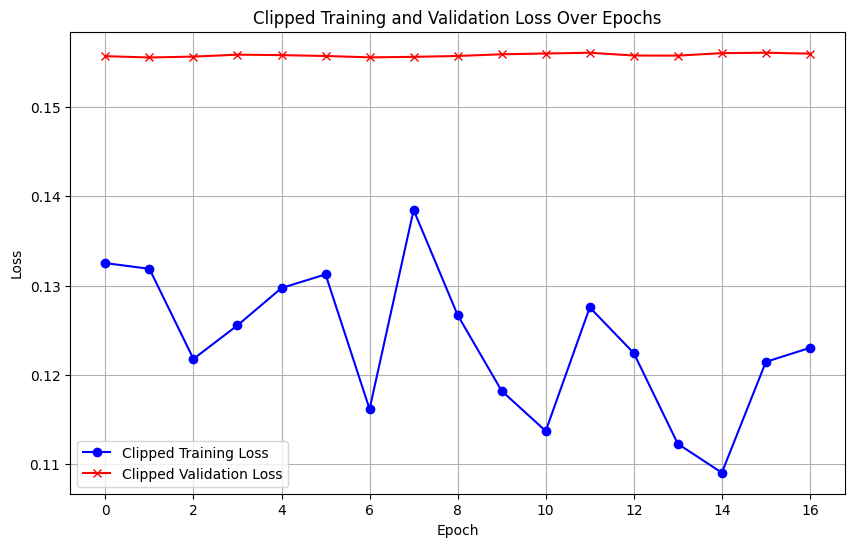

In [ ]:
import matplotlib.pyplot as plt

train_losses = trainer_result['train_loss']
val_losses = trainer_result['loss']  # Assuming 'loss' contains the validation losses

max_loss = 1  # Set a threshold for maximum loss to visualize

clipped_train_losses = [min(loss, max_loss) for loss in train_losses]
clipped_val_losses = [min(loss, max_loss) for loss in val_losses]

plt.figure(figsize=(10, 6))
plt.plot(clipped_train_losses, label='Clipped Training Loss', color='blue', marker='o')
plt.plot(clipped_val_losses, label='Clipped Validation Loss', color='red', marker='x')
plt.title('Clipped Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## ⭐ Evaluate

In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()

from torchvision.utils import save_image
from dataset import reconstruct_patched

def simple_micrograph_preprocessing(micrograph):
  micrograph_copy = micrograph.copy()
  micrograph_copy = (micrograph_copy-micrograph.mean()+2.5*micrograph.std())/5/micrograph.std()
  micrograph_copy[micrograph_copy<0]=0
  micrograph_copy[micrograph_copy>1]=1
  return micrograph_copy

!mkdir {RESULT_DIR}/Each_ckpt

### ⏭ Test score for all saved checkpoint.

In [ ]:
# Check the last five best epochs
if not user:
    model = model_post
    checkpoint_paths = [path for path in os.listdir(RESULT_DIR) if '.pt' in path]
    for checkpoint_path in checkpoint_paths[-5:]:
        state_dict_path = f"{RESULT_DIR}/{checkpoint_path}"
        state_dict = torch.load(state_dict_path, map_location=torch.device(DEVICE))
        model.load_state_dict(state_dict, strict=False)
        model.eval()
        print("\nLoad model at: ", state_dict_path)
        #trainer = CryoEMTrainerWithScheduler(model, train_dataset, criterion, optimizer, device,
        #              num_classes=NUM_CLASSES,
        #              lr_scheduler=scheduler, patience=ES_PATIENCE)
        #result = trainer.evaluate(test_loader)
        model.to(DEVICE)
        model.eval()
        mini_batch_size = 9  # Number of patches to process at once
        with torch.no_grad():
            idx, (test_image, _, grid, _) = next(enumerate(test_dataset))
            inputs = test_image.to(DEVICE)
            num_batches = (inputs.size(0) + mini_batch_size - 1) // mini_batch_size
            patched_outputs = []

            for batch_idx in range(num_batches):
                start_idx = batch_idx * mini_batch_size
                end_idx = min(start_idx + mini_batch_size, inputs.size(0))
                patch_input = inputs[start_idx:end_idx].to(DEVICE)
                output = model(patch_input)['out']
                patched_outputs.append(output.cpu())  # Move to CPU to conserve GPU memory

                del patch_input
                torch.cuda.empty_cache()
            outputs = torch.cat(patched_outputs).to(DEVICE)  # Move to CPU to conserve GPU memory
            del patched_outputs
            torch.cuda.empty_cache()
            preds = outputs.argmax(dim=1).unsqueeze(1).cpu().detach()  # Now preds will have shape [81, 1, 512, 512]

            ## Plotting
            micrograph = np.load(f"{IMAGE_DIR}/val/{val_filenames[idx][:-4]}.npy")
            label_path = f"{LABEL_DIR}/{val_filenames[idx][:-4]}.png"


            micrograph_copy = simple_micrograph_preprocessing(micrograph)
            #crop_amount = 128  # Amount cropped from each side of the label image
            mic_width, mic_height = micrograph_copy.shape[1], micrograph_copy.shape[0]

            # Calculate starting and ending indices for cropping the micrograph
            #start_x = int((mic_width - 3840) / 2)
            #end_x = start_x + 3840
            #start_y = int((mic_height - 3840) / 2)
            #end_y = start_y + 3840

            # Crop the micrograph
            cropped_micrograph = micrograph_copy
            pred_image = reconstruct_patched(preds, grid).float()

            _,ax = plt.subplots(figsize=(12, 12))
            ax.imshow(cropped_micrograph, cmap='gray')
            ax.imshow(pred_image.squeeze(), cmap='inferno', alpha=0.4)
            plt.show()
            ##

            filename = f"{os.path.splitext(checkpoint_path)[0]}.png"
            pred_path = os.path.join(RESULT_DIR, "Each_ckpt", filename)
            save_image(pred_image, pred_path)

### ✅ Testing

In [ ]:
model = model_post
CHECKPOINT_PATH = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/results/10017/unet_eb5_dice_CDCRF/checkpoint2.pt" # @param {type:"string"}
state_dict_path = CHECKPOINT_PATH
state_dict = torch.load(state_dict_path, map_location=torch.device(DEVICE))
model.load_state_dict(state_dict, strict=False)
model.to(DEVICE)
model.eval()
print("Load model at: ", state_dict_path)

Load model at:  /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/results/10017/unet_eb5_dice_CDCRF/checkpoint2.pt


In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [ ]:
if not user:
    test_dir = os.path.join(IMAGE_DIR, 'test')
    test_filenames = np.loadtxt(f"{IMAGE_DIR}/test_filenames.txt", dtype=str)
    np.random.seed(24)
    selected_filenames = np.random.choice(test_filenames, size=6, replace=False)
    print(selected_filenames)
    test_dataset = MicrographDatasetEvery(image_dir=test_dir, label_dir=LABEL_DIR, filenames=selected_filenames, crop_size=CROP_SIZE)
    test_loader = DataLoader(test_dataset, batch_size=None, shuffle=False, pin_memory=True)

In [ ]:
evaluator = CryoEMEvaluator(
    model=model, device=DEVICE, metrics=['AP','iou'],
    num_classes=NUM_CLASSES)
print("ConvCRF validation result:")
result = evaluator.evaluate(loader=val_loader)
if not user:
    print("ConvCRF test result:")
    result = evaluator.evaluate(loader=test_loader)

ConvCRF validation result:
torch.Size([81, 1, 512, 512])
torch.Size([81, 1, 512, 512])
torch.Size([81, 1, 512, 512])
torch.Size([81, 1, 512, 512])
torch.Size([81, 1, 512, 512])
torch.Size([81, 1, 512, 512])
Iou by Class: [0.8739274 0.637345 ]
Precision by Class: [0.94781226 0.73973864]
Recall by Class: [0.91810626 0.8215711 ]
Accuracy by Class: [0.89679414 0.89679414]
F1_score by Class: [0.9327228  0.77851033]


In [ ]:
# @markdown ---
# @markdown time used
end_time = time.time()
print(f"End time recorded: {end_time}")

elapsed_time = end_time - start_time
elapsed_time = elapsed_time


hours = int(elapsed_time // 3600)
remaining_seconds = elapsed_time % 3600

minutes = int(remaining_seconds // 60)
seconds = round(remaining_seconds % 60, 3)

print(f"Time spend : {hours} h, {minutes} m, {seconds} s")


gpu_used = "L4" # @param ["CPU high", "T4", "T4 high", "L4"]
per_unit_cost_dict = {"L4" : 1.71, "T4 high" : 1.41, "T4" : 1.19, "CPU high" :  0.24}
per_unit_cost = per_unit_cost_dict[gpu_used]
print(f"unit price per hr {per_unit_cost}")

cost_units = per_unit_cost * elapsed_time / 3600

per_unit_US = 10.49 / 100

cost_price_US = cost_units * per_unit_US

print(f"unit cost : {round(cost_units, 4)}")
print(f"unit price US: {cost_price_US}")
print(f"unit price NTD: {cost_price_US * 30.76}")

End time recorded: 1761992649.3462284
Time spend : 0 h, 28 m, 51.93 s
unit price per hr 1.71
unit cost : 0.8227
unit price US: 0.08629772991340935
unit price NTD: 2.6545181721364717
